# Capstone 2 - Analyzing Sales with Python

## Sales Territory Analysis

### Project Overview
This notebook presents a sales territory analysis for **EmporiUm**, a fictional retail company that sells textbooks, technology products, art supplies, and other merchandise both in-store and online. The purpose of this project is to analyze sales performance using Python, Pandas, and Matplotlib, and to extract insights that can support marketing and business decisions.

### Sales Territories Analyzed
The analysis focuses on two assigned sales territories within the **Northeast region**:
- **Sales Territory 1:** Maine  
- **Sales Territory 2:** Massachusetts  

### Objectives
The main objectives of this analysis are to:
- Examine monthly revenue trends across both territories  
- Compare sales performance between Maine and Massachusetts  
- Analyze customer purchasing behavior  
- Evaluate product category performance  
- Provide data-driven marketing recommendations based on the findings  

This notebook walks through the full data analysis process, including data cleaning, exploration, visualization, and interpretation of results.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

#### Customer List Data

In [2]:
customers = pd.read_csv("customer_list.csv", sep="|")
customers.info()
customers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


#### Store Sales Data

In [3]:
storesales = pd.read_csv("StoreSales.csv")
storesales.info()
storesales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


#### Store Detail Data

In [4]:
stored = pd.read_csv("StoreDetail.csv")
stored.info()
stored.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


#### Products Data

In [5]:
products = pd.read_csv("Products.csv")
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


#### Product Categories Data 

In [6]:
pcategories = pd.read_csv("ProductCategories.csv")
pcategories.info()
pcategories.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


# Core Marking Analysis

### Question 1 - Territory Managers and Store Information
This table shows the territory managers responsible for stores located in Maine and Massachusetts within the Northeast region. It also includes store IDs and city locations associated with each territory.

This information provides a clear overview of store coverage and territory distribution, helping management understand how sales responsibilities are organized across the Northeast region and supporting further analysis of performance, customer activity, and product trends.

Sales Territory 1 = Maine

Sales Territory 2 = Massachusetts

In [31]:
# Who are the territory managers for the sales territories assigned? What are the store IDs and cities
# for the stores in each assigned sales territory?
Northeast = stored[stored['State'].isin(['Maine', 'Massachusetts'])]
Northeast
# Territory Manager for Maine is Erbayne Middleton ( Stores 818-823)
# Territory Manager for Massachusetts is Bo Heap ( Stores 730 and 801-817)

,Store Location,State,Store ID,Territory Manager,Region,Region Director
37,Bangor,Maine,818,Erbayne Middleton,Northeast,Michael Jarvis
38,Bar Harbor,Maine,819,Erbayne Middleton,Northeast,Michael Jarvis
39,Kennebunkport,Maine,820,Erbayne Middleton,Northeast,Michael Jarvis
40,Lewiston,Maine,821,Erbayne Middleton,Northeast,Michael Jarvis
41,Orono,Maine,822,Erbayne Middleton,Northeast,Michael Jarvis
42,South Portland,Maine,823,Erbayne Middleton,Northeast,Michael Jarvis
52,Boston,Massachusetts,730,Bo Heap,Northeast,Michael Jarvis
53,Attleboro,Massachusetts,801,Bo Heap,Northeast,Michael Jarvis
54,Falmouth,Massachusetts,802,Bo Heap,Northeast,Michael Jarvis
55,Framingham,Massachusetts,803,Bo Heap,Northeast,Michael Jarvis


### Question 2 - Montly Revenue Analysis
This report presents the monthly total revenue from in-store sales across the two assigned sales territories over the entire time period included in the dataset.

In [32]:
# What is monthly total revenue for in-store sales in each of the two sales territories, over the full
# period covered by the data?

# Merge sales with store details
sales_store = pd.merge(
    storesales,
    stored,
    on = 'Store ID')

# keep only Maine and Massachusetts 
northeast_sales = sales_store[
    sales_store['State'].isin(['Maine', 'Massachusetts'])] 

# Convert data column // pd.to_datetime() converts text dates into real date format
northeast_sales['Transaction Date'] = pd.to_datetime(
    northeast_sales['Transaction Date'])

# Create Month Column
northeast_sales['Month'] = northeast_sales['Transaction Date'].dt.to_period('M')

# Finding Montly revenue
monthly_revenue = northeast_sales.groupby(['State', 'Month'])['Sale Amount'].sum().reset_index() #reset_index() turns grouped indexes back into columns

monthly_revenue


C:\Users\nataliamiranda\AppData\Local\Temp\ipykernel_22452\1933332500.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  northeast_sales['Transaction Date'] = pd.to_datetime(
C:\Users\nataliamiranda\AppData\Local\Temp\ipykernel_22452\1933332500.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  northeast_sales['Month'] = northeast_sales['Transaction Date'].dt.to_period('M')


,State,Month,Sale Amount
0,Maine,2022-01,15700.31
1,Maine,2022-02,21008.29
2,Maine,2022-03,23173.23
3,Maine,2022-04,20169.19
4,Maine,2022-05,22631.11
...,...,...,...
91,Massachusetts,2025-08,174867.46
92,Massachusetts,2025-09,168503.25
93,Massachusetts,2025-10,277382.19
94,Massachusetts,2025-11,196108.93


### Question 3 - Store Performance Ranking
This analysis evaluates and ranks the sales performance of each store within the assigned sales territories to identify the top-performing stores.

In [91]:
# How would you rank the sales performance of each store in each sales territory? Which are the
# top-performing stores?

store_performance = northeast_sales.groupby(
    ['State', 'Store ID', 'Store Location']
)['Sale Amount'].sum().reset_index()

# Ranking highest sales first 
store_performance = store_performance.sort_values(
    by='Sale Amount',
    ascending = False
)

store_performance

,State,Store ID,Store Location,Sale Amount
23,Massachusetts,817,Worcester,602183.44
13,Massachusetts,807,Leominster,338009.10
16,Massachusetts,810,Nantucket,335547.81
5,Maine,823,South Portland,332611.76
4,Maine,822,Orono,330505.47
20,Massachusetts,814,Provincetown,328860.51
18,Massachusetts,812,Northampton,322039.24
2,Maine,820,Kennebunkport,321998.55
12,Massachusetts,806,Holyoke,320516.53
22,Massachusetts,816,Somerville,312873.59


In [92]:
## To show TOP 3 STORES ONLY
store_performance.head(3)

,State,Store ID,Store Location,Sale Amount
23,Massachusetts,817,Worcester,602183.44
13,Massachusetts,807,Leominster,338009.10
16,Massachusetts,810,Nantucket,335547.81


### Question 4 - Top Customers by Territory
This analysis identifies the top customers in each sales territory by comparing customer IDs from the customer list with rewards IDs from the sales data.

In [66]:
# Comparing the customer ID from the customer list data with the rewards ID from the sales data,
# who were the top customers in each sales territory?

customer_sales = pd.merge(
    northeast_sales,
    customers,
    left_on = 'RewardsID',
    right_on = 'cust_id',
    how = 'inner'
)

top_customers = customer_sales.groupby(
    ['State', 'cust_id','RewardsID', 'name',]
)['Sale Amount'].sum().reset_index()


top_customers = top_customers.sort_values(
    by = 'Sale Amount',
    ascending = False
)

# top_customers[top_customers['State'] == 'Maine'].head()

# top_customers[top_customers['State'] == 'Massachusetts'].head()


In [93]:
# View results
top_customers[top_customers['State'] == 'Maine'].head()

,State,cust_id,RewardsID,name,Sale Amount
384,Maine,421,421.0,Rosita,3637.75
80,Maine,89,89.0,Karen Walker,3362.83
313,Maine,345,345.0,Maddy Perez,2706.42
8,Maine,9,9.0,Mike H.,2695.22
186,Maine,208,208.0,Philip Banks,2662.84


In [68]:
top_customers[top_customers['State'] == 'Massachusetts'].head()


,State,cust_id,RewardsID,name,Sale Amount
771,Massachusetts,292,292.0,Beverly Crusher,4758.92
863,Massachusetts,384,384.0,Tracy Jordan,4197.55
526,Massachusetts,47,47.0,Stanley H.,3979.73
482,Massachusetts,3,3.0,Monica Geller,3966.91
667,Massachusetts,188,188.0,Mellie Grant,3948.41


## Question 5 - Montly Transactions and Revenue Analysis by Product Category
This analysis examines the number of monthly transactions by product category across the assigned sales territories, as well as the total monthly sales revenue by category.

It also explores what these patterns reveal about the most popular products and identifies potential opportunities for growth

### Number of Transactions Per Month by Product Category 

In [95]:
# What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? 
# What might this tell you about the most popular products, and where could there be opportunity for growth?

# Merge sales with store details
sales_products = storesales.merge(stored, on = 'Store ID')

# Merge with products
sales_products = sales_products.merge(
    products, on = 'Prod Num')

# Merge with product categories 
sales_products = sales_products.merge(
    pcategories, on = ['CategoryID', 'SubcategoryID'])


## Filter only Maine and Massachusetts
territory_sales = sales_products[
    sales_products['State'].isin(['Maine','Massachusetts'])]  

## Convert Transaction Date to datetime 
territory_sales['Transaction Date'] = pd.to_datetime( 
    territory_sales['Transaction Date']
)
# create month column
territory_sales['Month'] = territory_sales[
    'Transaction Date'
].dt.to_period('M')

monthly_transactions = territory_sales.groupby(
    ['State','Month', 'Category']
)['Prod Num'].count().reset_index()


monthly_transactions = monthly_transactions.rename(
    columns={'Prod Num': 'Transaction Count'})

monthly_transactions




C:\Users\nataliamiranda\AppData\Local\Temp\ipykernel_22452\2391814395.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  territory_sales['Transaction Date'] = pd.to_datetime(
C:\Users\nataliamiranda\AppData\Local\Temp\ipykernel_22452\2391814395.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  territory_sales['Month'] = territory_sales[


,State,Month,Category,Transaction Count
0,Maine,2022-01,Apparel and Merchandise,30
1,Maine,2022-01,Art Supplies,33
2,Maine,2022-01,Books (General),12
3,Maine,2022-01,Stationery and Supplies,29
4,Maine,2022-01,Technology & Accessories,35
...,...,...,...,...
571,Massachusetts,2025-12,Art Supplies,256
572,Massachusetts,2025-12,Books (General),105
573,Massachusetts,2025-12,Stationery and Supplies,267
574,Massachusetts,2025-12,Technology & Accessories,293


### Analysis 
This analysis shows the number of transactions for each product category by month in Maine and Massachusetts. 
Categories with higher transaction counts may represent the most popular product among customers.

### Total Sales Revenue Per Month by Product Category 

In [98]:
# Total Revenue by month and category 
monthly_revenue = territory_sales.groupby(
    ['State','Month', 'Category'])['Sale Amount'].sum().reset_index()

# Format revenue column
monthly_revenue['Sale Amount'] = monthly_revenue['Sale Amount'].map('${:,.2f}'.format)

monthly_revenue





,State,Month,Category,Sale Amount
0,Maine,2022-01,Apparel and Merchandise,$958.97
1,Maine,2022-01,Art Supplies,$874.56
2,Maine,2022-01,Books (General),$370.52
3,Maine,2022-01,Stationery and Supplies,$232.05
4,Maine,2022-01,Technology & Accessories,"$9,007.64"
...,...,...,...,...
571,Massachusetts,2025-12,Art Supplies,"$7,565.62"
572,Massachusetts,2025-12,Books (General),"$2,971.77"
573,Massachusetts,2025-12,Stationery and Supplies,"$2,697.55"
574,Massachusetts,2025-12,Technology & Accessories,"$144,387.39"


### Analysis
This analysis shows total sales revenue for each product category by month. 
Categories generating the highest revenue may represent the strongest opportunities for continued marketing investment and customers engagement.

## What is your recommendation for where to focus marketing attention in the next quarter?

Based on the analysis, marketing efforts should focus on the product categories with the highest transaction counts and revenue totals 
in Maine and Massachusetts.
High-performing categories show strong customer demand and could benefit from additional promotions, loyal campaigns, and seasonal advertising.
Lower-performing categories may represent opportunities for growth through targeted discounts or improved product visibility.
    

# CHART 1 BASED ON QUESTION 2 


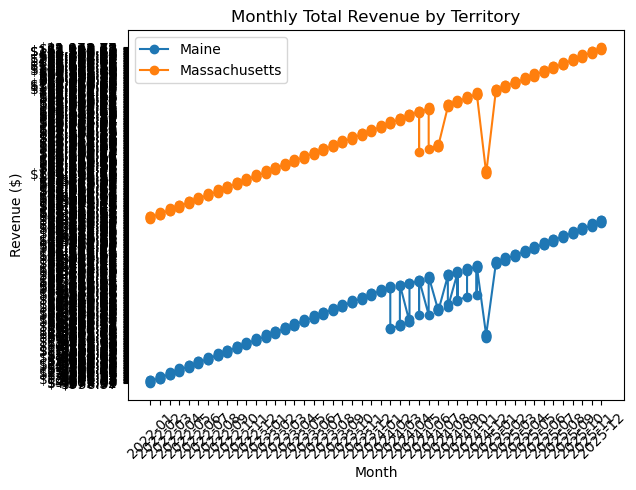

In [121]:
# Separate data by state
maine = monthly_revenue[monthly_revenue['State'] == 'Maine']
mass = monthly_revenue[monthly_revenue['State'] == 'Massachusetts']

# Line chart
plt.plot(maine['Month'].astype(str), maine['Sale Amount'], marker='o', label='Maine')
plt.plot(mass['Month'].astype(str), mass['Sale Amount'], marker='o', label='Massachusetts')

# Labels and title
plt.title('Monthly Total Revenue by Territory')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')

# Improve readability
plt.xticks(rotation=45)
plt.legend()

plt.show()


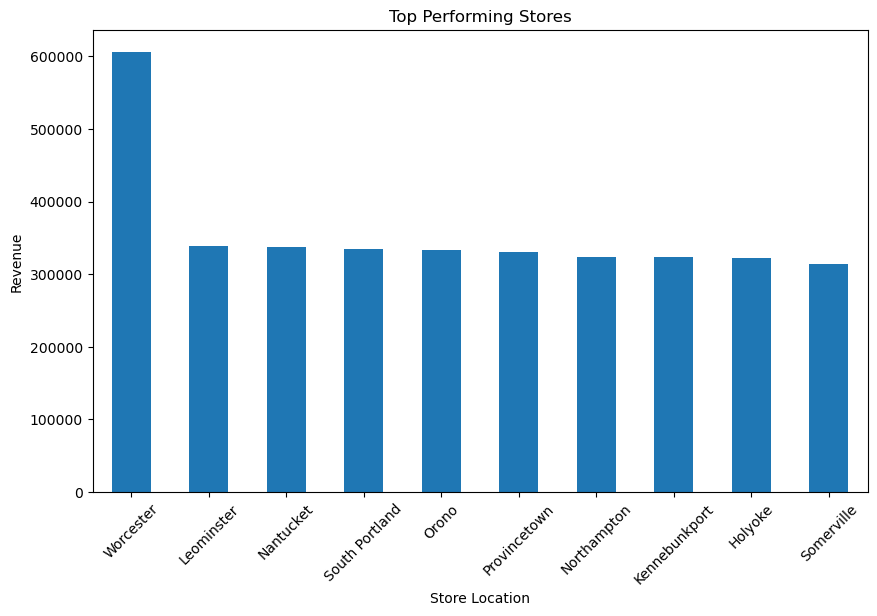

In [123]:

# Store Sales Performance Rankings
top_stores = territory_sales.groupby(
    'Store Location'
)['Sale Amount'].sum().sort_values(
    ascending = False
).head(10)

top_stores.plot(
    kind='bar', 
    figsize = (10,6))

plt.title('Top Performing Stores')
plt.xlabel('Store Location')
plt.ylabel('Revenue')

plt.xticks(rotation = 45)

plt.show()

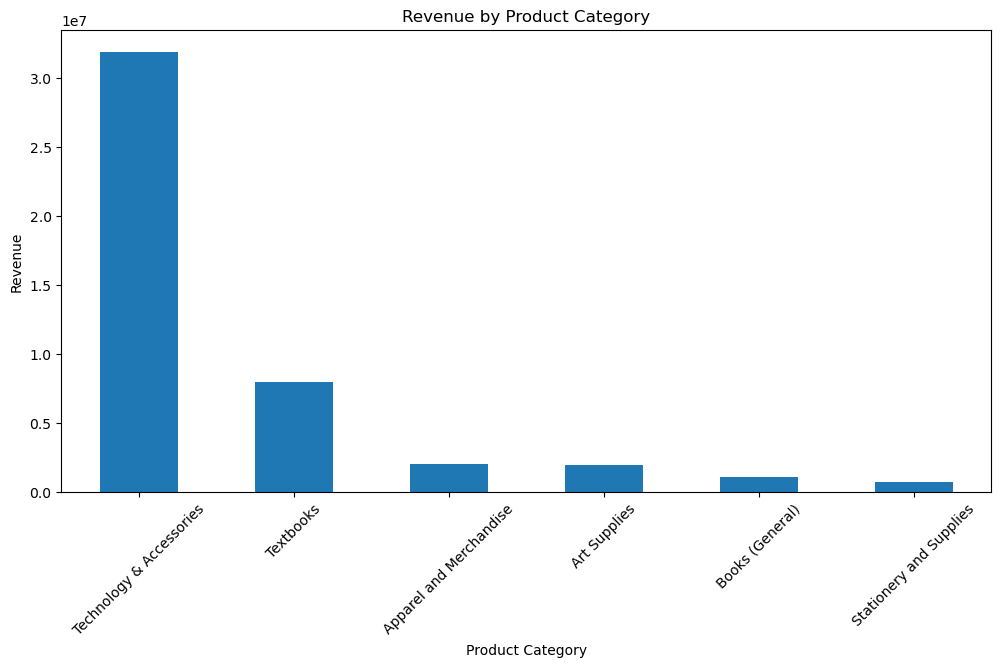

In [125]:
category_revenue = sales_full.groupby(
    'Category'
)['Sale Amount'].sum().sort_values(ascending= False)

category_revenue.plot(
    kind='bar',
    figsize=(12,6))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.show()